This code is used for answering question 3 of assignment 3 for the course CH28: Molecular Systems Biology (Spring 2025)
This code is used to generate 10 independent trajectories for protein and mRNA levels over time using Gillespie SSA. Plots for visualising the simulation are also generated here.

The code has been altered from code for simulating transcriptional bursting (https://colab.research.google.com/drive/1A5GxZ4IWa5nI44VE0I8fw_iTI1bN9qSJ?usp=sharing) 

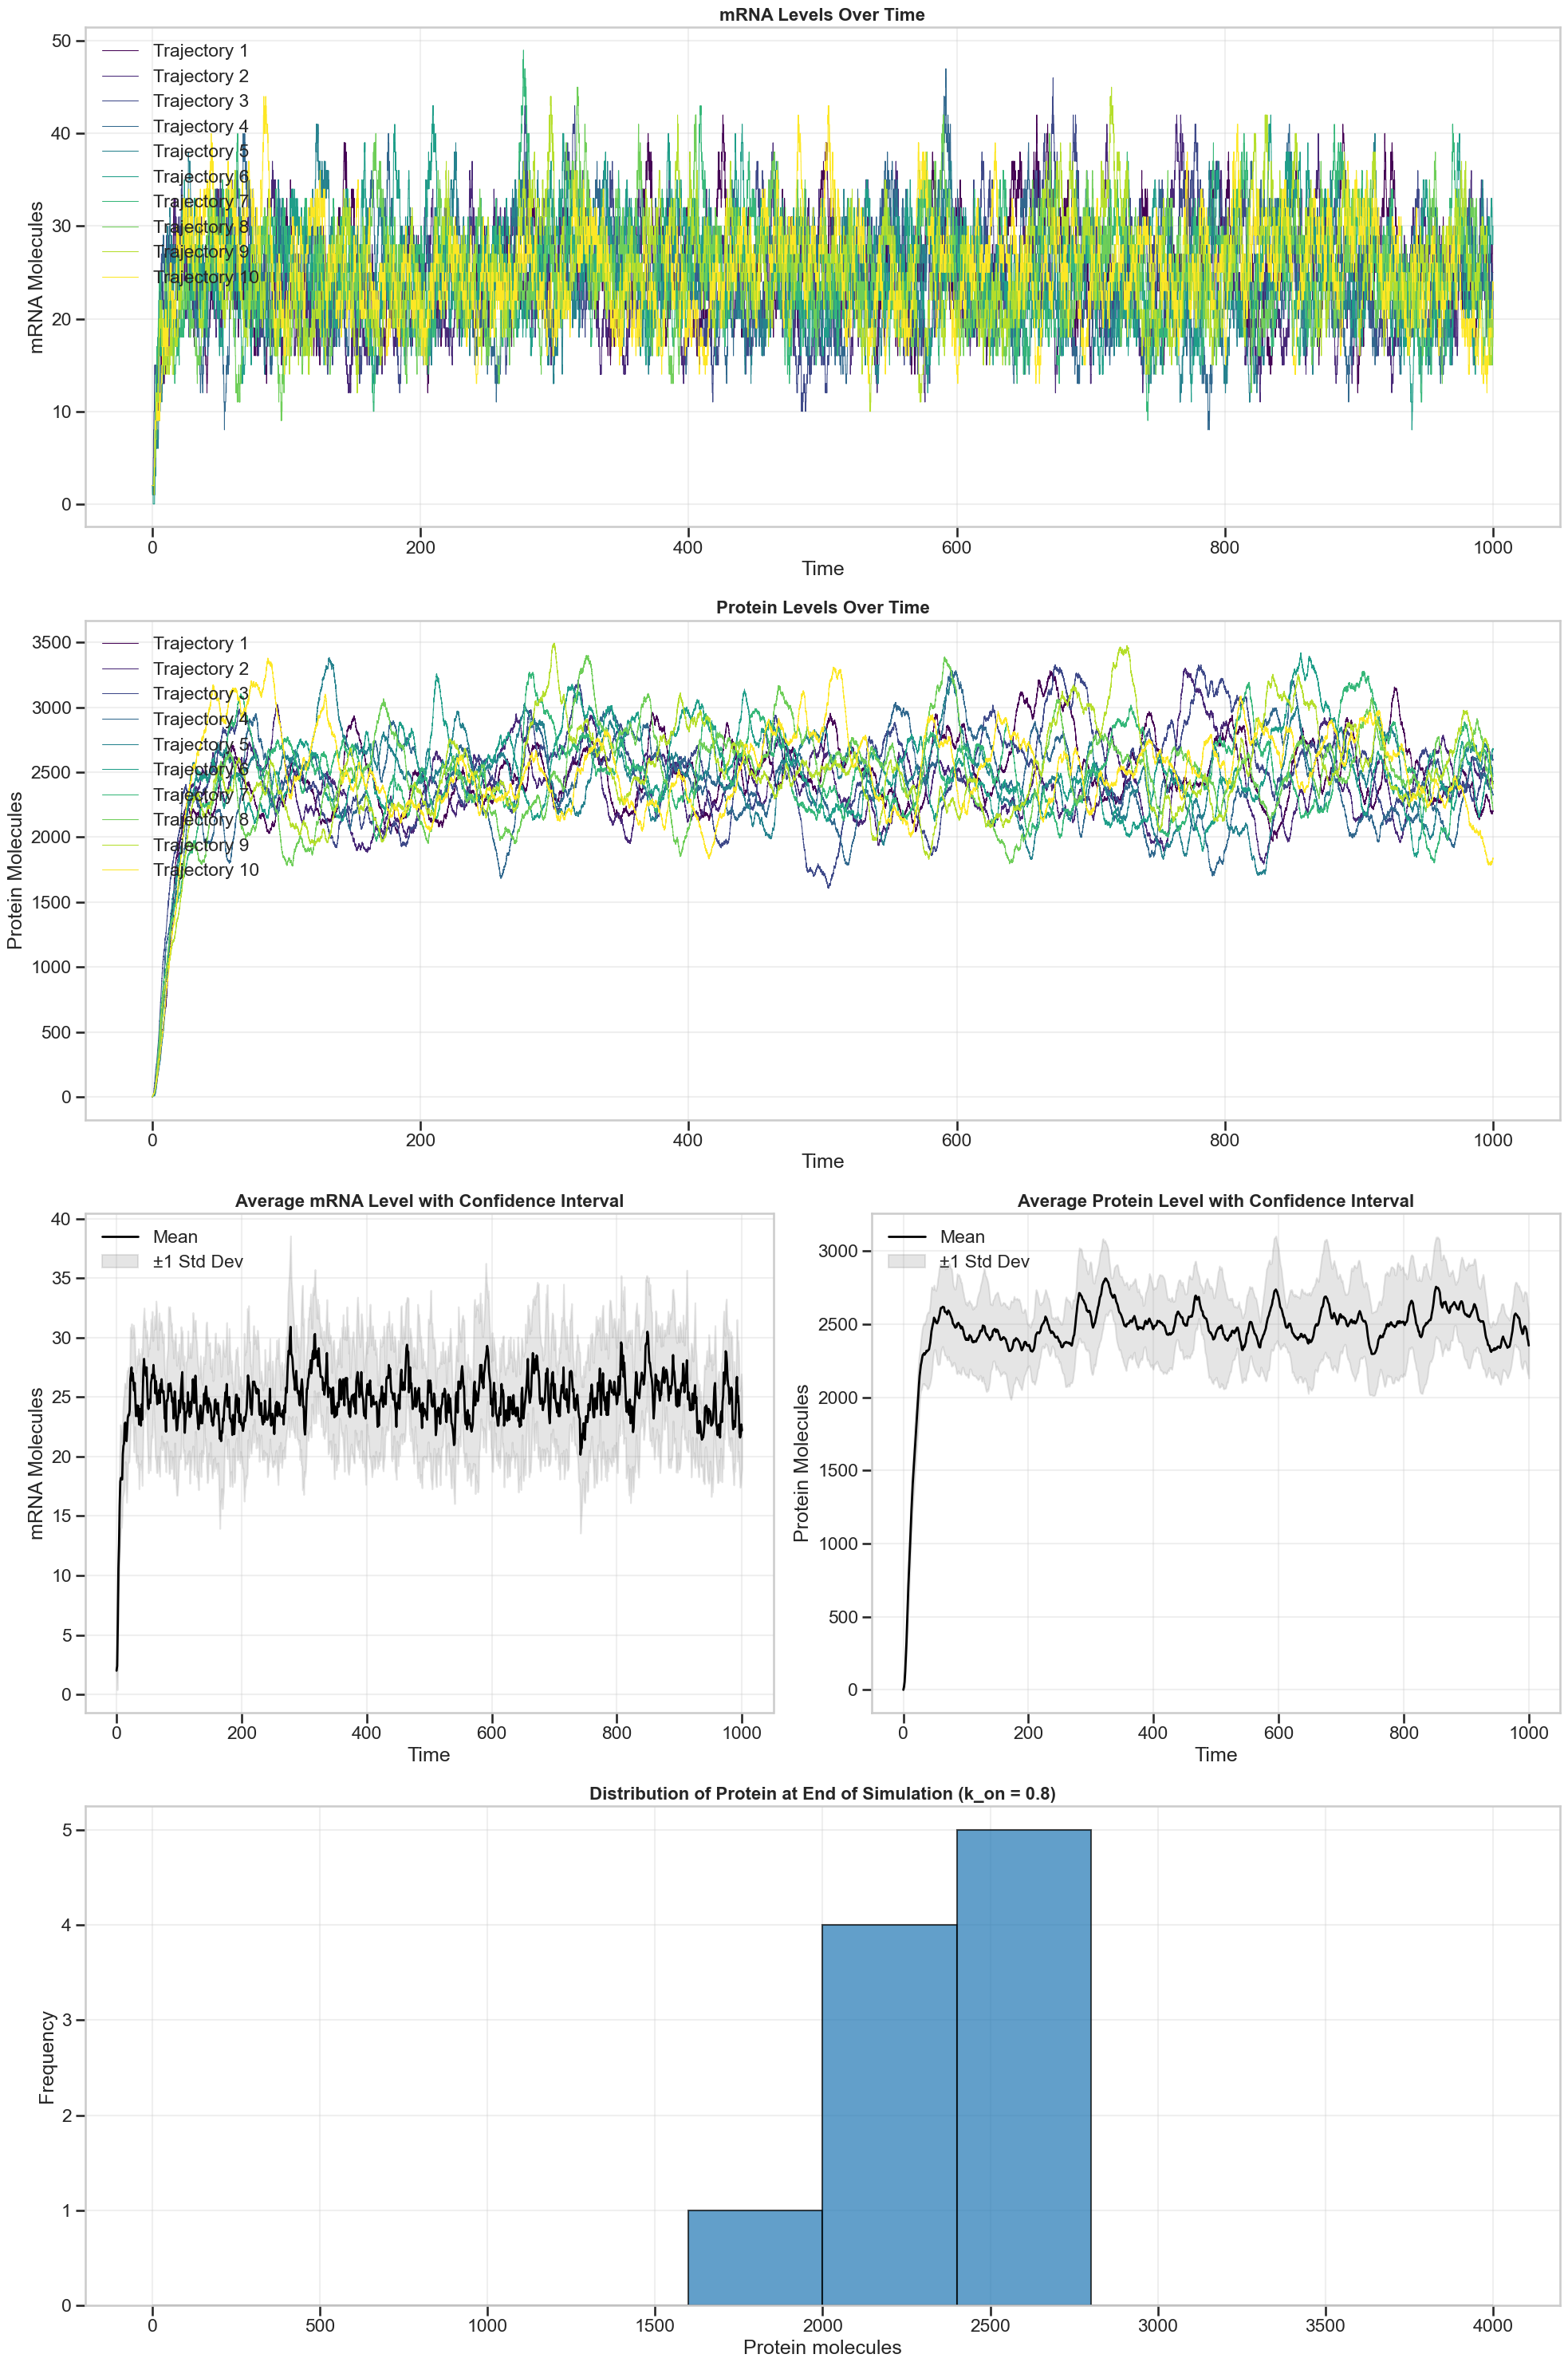

Simulation Parameters:
  k_on: 0.1
  k_off: 0.05
  k_basal: 0.05
  k_m: 5.0
  k_P: 10.0
  gamma_R: 0.2
  gamma_P: 0.1
  P_total: 0
  R_total: 2
  t_max: 1000
  n_trajectories: 10

Statistics at t = 1000:
  Mean mRNA: 22.20
  Std Dev mRNA: 3.25
  Coefficient of Variation: 0.15

Statistics at t = 1000:
  Mean Protein: 2353.70
  Std Dev Protein: 223.00
  Coefficient of Variation: 0.09


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

class TranscriptionalBurstingSSA:
    def __init__(self, parameters=None):
        # Default parameters if none provided
        if parameters is None:
            self.parameters = {
                'k_on': 0.1,       # D + P -> D* rate
                'k_off': 0.05,     # D* -> D + P rate
                'k_basal': 0.05,   # D -> D + R (basal transcription rate)
                'k_m': 5.0,        # mRNA production rate
                'k_P': 10.0,       # Protein translation rate
                'gamma_R': 0.2,    # mRNA degradation rate
                'gamma_P': 0.1,    # Protein degradation rate
                'P_total': 0,      # Total protein molecules (initial)
                'R_total': 2,      # Total mRNA molecules (initial)
                't_max': 1000,      # Maximum simulation time
                'n_trajectories': 10  # Number of trajectories to simulate
            }
        else:
            self.parameters = parameters

        # Initialize state
        self.initialize_state()

        # Define reaction propensity functions
        self.propensity_functions = [
            lambda x: self.parameters['k_basal'] * x[0],               # D -> D + R (basal transcription)
            lambda x: self.parameters['k_on'] * x[0] * x[1],           # D + P -> D*
            lambda x: self.parameters['k_off'] * x[2],                 # D* -> D + P
            lambda x: self.parameters['k_m'] * x[2],                   # D* -> D* + R
            lambda x: self.parameters['k_P'] * x[3],                   # R -> R + P
            lambda x: self.parameters['gamma_R'] * x[3],               # R -> 0 (mRNA degradation)
            lambda x: self.parameters['gamma_P'] * x[1],               # P -> 0 (protein degradation)
        ]

        # Define state change vectors
        self.state_change_vectors = np.array([
            [0, 0, 0, 1],       # D -> D + R
            [-1, -1, 1, 0],     # D + P -> D*
            [1, 1, -1, 0],      # D* -> D + P
            [0, 0, 0, 1],       # D* -> D* + R
            [0, 1, 0, 0],       # R -> R + P
            [0, 0, 0, -1],      # R -> 0
            [0, -1, 0, 0],      # P -> 0
        ])

    def initialize_state(self):
        # Initial state: [D, P, D*, R]
        self.state = np.array([
            1,                          # D (promoter)
            self.parameters['P_total'], # P (transcription factor/protein)
            0,                          # D* (active promoter)
            self.parameters['R_total'], # R (mRNA)
        ])

        self.time = 0.0
        self.times = [self.time]
        self.states = [self.state.copy()]

    def calculate_propensities(self):
        return np.array([f(self.state) for f in self.propensity_functions])

    def gillespie_step(self):
        # Calculate propensities
        propensities = self.calculate_propensities()
        total_propensity = np.sum(propensities)

        # If total propensity is zero, no reactions can occur
        if total_propensity == 0:
            return False

        # Generate random numbers
        r1, r2 = np.random.random(2)

        # Calculate time increment
        tau = (1.0 / total_propensity) * np.log(1.0 / r1)

        # Determine which reaction occurs
        cumulative_propensities = np.cumsum(propensities)
        reaction_index = np.searchsorted(cumulative_propensities, r2 * total_propensity)

        # Update state and time
        self.state = self.state + self.state_change_vectors[reaction_index]
        self.time += tau

        # Record state and time
        self.times.append(self.time)
        self.states.append(self.state.copy())

        return True

    def run_simulation(self):
        while self.time < self.parameters['t_max']:
            if not self.gillespie_step():
                break

        # Convert lists to numpy arrays for easier analysis
        self.times = np.array(self.times)
        self.states = np.array(self.states)

        return self.times, self.states

    def run_multiple_trajectories(self):
        all_trajectories = []
        all_times = []

        for i in range(self.parameters['n_trajectories']):
            self.initialize_state()
            times, states = self.run_simulation()
            all_trajectories.append(states)
            all_times.append(times)

        return all_times, all_trajectories

# Run the simulation
np.random.seed(42)  # For reproducibility
simulator = TranscriptionalBurstingSSA()
all_times, all_trajectories = simulator.run_multiple_trajectories()

# Set up a nice style for the plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")
colors = plt.cm.viridis(np.linspace(0, 1, simulator.parameters['n_trajectories']))

# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 30))
gs = GridSpec(4, 2, figure=fig)

# 1. Plot mRNA levels for all trajectories
ax1 = fig.add_subplot(gs[0, :])
for i, (times, states) in enumerate(zip(all_times, all_trajectories)):
    ax1.plot(times, states[:, 3], color=colors[i], lw=0.75, label=f'Trajectory {i+1}')
ax1.set_xlabel('Time')
ax1.set_ylabel('mRNA Molecules')
ax1.set_title('mRNA Levels Over Time', fontsize=16, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Plot protein levels for all trajectories
ax1 = fig.add_subplot(gs[1, :])
for i, (times, states) in enumerate(zip(all_times, all_trajectories)):
    ax1.plot(times, states[:, 1], color=colors[i], lw=0.75, label=f'Trajectory {i+1}')
ax1.set_xlabel('Time')
ax1.set_ylabel('Protein Molecules')
ax1.set_title('Protein Levels Over Time', fontsize=16, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)


# 3. Plot average mRNA level over time with confidence interval
ax5 = fig.add_subplot(gs[2, 0])
# Resample all trajectories to a common time grid for averaging
common_times = np.linspace(0, simulator.parameters['t_max'], 1000)
resampled_mrna = []

for i, (times, states) in enumerate(zip(all_times, all_trajectories)):
    # Simple linear interpolation
    mrna_interp = np.interp(common_times, times, states[:, 3])
    resampled_mrna.append(mrna_interp)

resampled_mrna = np.array(resampled_mrna)
avg_mrna = np.mean(resampled_mrna, axis=0)
std_mrna = np.std(resampled_mrna, axis=0)

ax5.plot(common_times, avg_mrna, 'k-', lw=2, label='Mean')
ax5.fill_between(common_times, avg_mrna - std_mrna, avg_mrna + std_mrna, alpha=0.2, color='gray', label='±1 Std Dev')
ax5.set_xlabel('Time')
ax5.set_ylabel('mRNA Molecules')
ax5.set_title('Average mRNA Level with Confidence Interval', fontsize=16, fontweight='bold')
ax5.legend(loc='upper left')
ax5.grid(True, alpha=0.3)

# 4. Plot average Protein level over time with confidence interval
ax5 = fig.add_subplot(gs[2, 1])
# Resample all trajectories to a common time grid for averaging
common_times = np.linspace(0, simulator.parameters['t_max'], 1000)
resampled_mrna = []

for i, (times, states) in enumerate(zip(all_times, all_trajectories)):
    # Simple linear interpolation
    mrna_interp = np.interp(common_times, times, states[:, 1])
    resampled_mrna.append(mrna_interp)

resampled_mrna = np.array(resampled_mrna)
avg_mrna = np.mean(resampled_mrna, axis=0)
std_mrna = np.std(resampled_mrna, axis=0)

ax5.plot(common_times, avg_mrna, 'k-', lw=2, label='Mean')
ax5.fill_between(common_times, avg_mrna - std_mrna, avg_mrna + std_mrna, alpha=0.2, color='gray', label='±1 Std Dev')
ax5.set_xlabel('Time')
ax5.set_ylabel('Protein Molecules')
ax5.set_title('Average Protein Level with Confidence Interval', fontsize=16, fontweight='bold')
ax5.legend(loc='upper left')
ax5.grid(True, alpha=0.3)

# 5. Plot histogram of Protein levels at the end of simulation
ax4 = fig.add_subplot(gs[3, :])
final_protein = [traj[-1, 1] for traj in all_trajectories]
ax4.hist(final_protein, bins=10, range =[0,4000], alpha=0.7, edgecolor='black', color='#1f77b4',)
ax4.set_xlabel('Protein molecules')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Protein at End of Simulation (k_on = 0.8)', fontsize=16, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Visualization_positive feedback_loop_kbasal_on.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate and print statistics for final mRNA levels
final_states = np.array([traj[-1] for traj in all_trajectories])
mean_mrna = np.mean(final_states[:, 3])
std_mrna = np.std(final_states[:, 3])
cv_mrna = std_mrna / mean_mrna if mean_mrna > 0 else 0

print(f"Simulation Parameters:")
for key, value in simulator.parameters.items():
    print(f"  {key}: {value}")

print(f"\nStatistics at t = {simulator.parameters['t_max']}:")
print(f"  Mean mRNA: {mean_mrna:.2f}")
print(f"  Std Dev mRNA: {std_mrna:.2f}")
print(f"  Coefficient of Variation: {cv_mrna:.2f}")

# Caluclate and print statistics for final protein levels
final_states = np.array([traj[-1] for traj in all_trajectories])
mean_protein = np.mean(final_states[:, 1])
std_protein = np.std(final_states[:, 1])
cv_protein = std_protein / mean_protein if mean_protein > 0 else 0

print(f"\nStatistics at t = {simulator.parameters['t_max']}:")
print(f"  Mean Protein: {mean_protein:.2f}")
print(f"  Std Dev Protein: {std_protein:.2f}")
print(f"  Coefficient of Variation: {cv_protein:.2f}")


